# 09. ETF Ex-dividend Strategy Backtest

本 Notebook 是一份**獨立策略回測 Notebook**。

它不依賴前一份研究 Notebook 輸出的 CSV，而是從以下兩個 processed data 重新開始：

- `data/processed/etf_daily_panel.csv`
- `data/processed/etf_dividend_events.csv`

流程：

1. 讀取資料
2. 清洗 ETF symbol
3. 建立 ETF universe
4. 建立除息事件視窗資料
5. 建立 D-10 → D-1 除息前卡位策略
6. 比較多種 universe：
   - Naive All ETF
   - Filtered All ETF
   - Market Cap Core
   - High Dividend Core
7. 產出策略交易表、basket return、資金曲線、回撤、分 ETF 與分年度績效

> Strategy v1 目標：先確認「除息前 alpha」能否轉成策略級資金曲線。  
> 這不是最終正式回測，尚未處理公告日可交易性、實際資金占用、滑價與每日 portfolio simulation。


## 0. Import packages and set paths

In [22]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

PANEL_PATH = PROJECT_ROOT / "data" / "processed" / "etf_daily_panel.csv"
EVENTS_PATH = PROJECT_ROOT / "data" / "processed" / "etf_dividend_events.csv"

OUTPUT_DIR = PROJECT_ROOT / "data" / "strategy"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PANEL_PATH exists:", PANEL_PATH.exists(), PANEL_PATH)
print("EVENTS_PATH exists:", EVENTS_PATH.exists(), EVENTS_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: C:\Users\USER\Desktop\ETF-alpha-lab
PANEL_PATH exists: True C:\Users\USER\Desktop\ETF-alpha-lab\data\processed\etf_daily_panel.csv
EVENTS_PATH exists: True C:\Users\USER\Desktop\ETF-alpha-lab\data\processed\etf_dividend_events.csv
OUTPUT_DIR: C:\Users\USER\Desktop\ETF-alpha-lab\data\strategy


## 1. ETF symbol cleaning

台灣 ETF 代碼有 4 碼、5 碼、6 碼，不能一律 `.zfill(4)`。

例如：

- `0050`
- `0056`
- `00713`
- `00878`
- `00919`
- `006208`

如果 CSV 或 Excel 把前導零吃掉，必須用 mapping 修正。


In [23]:
def fix_tw_etf_symbol(x):
    """
    Normalize Taiwan ETF symbols while preserving leading zeros.

    Examples:
    - 50 -> 0050
    - 713 / 0713 -> 00713
    - 6208 -> 006208
    """

    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    symbol_fix_map = {
        "50": "0050",
        "0050": "0050",
        "52": "0052",
        "0052": "0052",
        "56": "0056",
        "0056": "0056",
        "713": "00713",
        "0713": "00713",
        "00713": "00713",
        "878": "00878",
        "0878": "00878",
        "00878": "00878",
        "919": "00919",
        "0919": "00919",
        "00919": "00919",
        "929": "00929",
        "0929": "00929",
        "00929": "00929",
        "939": "00939",
        "0939": "00939",
        "00939": "00939",
        "940": "00940",
        "0940": "00940",
        "00940": "00940",
        "6208": "006208",
        "006208": "006208",
    }

    if s in symbol_fix_map:
        return symbol_fix_map[s]

    if len(s) <= 4:
        return s.zfill(4)

    return s


# Quick sanity check
test_symbols = ["50", "0050", "713", "0713", "00713", "878", "6208", "006208"]
pd.DataFrame({
    "raw": test_symbols,
    "fixed": [fix_tw_etf_symbol(x) for x in test_symbols]
})


,raw,fixed
0,50,0050
1,0050,0050
2,713,00713
3,0713,00713
4,00713,00713
5,878,00878
6,6208,006208
7,006208,006208


## 2. Data loading functions

In [24]:
def load_etf_panel(panel_path):
    """Load ETF daily panel data."""

    panel = pd.read_csv(panel_path, dtype={"symbol": str})
    panel["symbol"] = panel["symbol"].apply(fix_tw_etf_symbol)

    if "date" in panel.columns:
        panel["date"] = pd.to_datetime(panel["date"], errors="coerce")

    panel = (
        panel
        .dropna(subset=["symbol", "date"])
        .sort_values(["symbol", "date"])
        .reset_index(drop=True)
    )

    return panel


def load_etf_dividend_events(events_path):
    """Load ETF dividend events data."""

    events = pd.read_csv(events_path, dtype={"symbol": str})
    events["symbol"] = events["symbol"].apply(fix_tw_etf_symbol)

    for col in ["ex_date", "record_date", "pay_date", "announcement_date"]:
        if col in events.columns:
            events[col] = pd.to_datetime(events[col], errors="coerce")

    events = (
        events
        .dropna(subset=["symbol", "ex_date"])
        .sort_values(["symbol", "ex_date"])
        .reset_index(drop=True)
    )

    return events


def build_valid_etf_universe(
    panel_all,
    event_summary,
    exclude_keywords=None,
):
    """Build valid ETF universe from panel and dividend event data."""

    if exclude_keywords is None:
        exclude_keywords = [
            "正2", "反1", "反向", "槓桿", "期貨", "VIX", "期信",
            "2X", "Bear", "Bull", "Inverse", "Leveraged",
        ]

    name_col = None

    for candidate in ["etf_name", "fund_name", "name"]:
        if candidate in panel_all.columns:
            name_col = candidate
            break

    if name_col is None:
        for candidate in ["etf_name", "fund_name", "name"]:
            if candidate in event_summary.columns:
                name_col = candidate
                break

    if name_col and name_col in panel_all.columns:
        etf_info = panel_all[["symbol", name_col]].drop_duplicates("symbol").copy()
    elif name_col and name_col in event_summary.columns:
        etf_info = event_summary[["symbol", name_col]].drop_duplicates("symbol").copy()
    else:
        etf_info = panel_all[["symbol"]].drop_duplicates().copy()
        etf_info["etf_name"] = ""
        name_col = "etf_name"

    etf_info["name_for_filter"] = etf_info[name_col].astype(str)
    etf_info["is_excluded_by_name"] = etf_info["name_for_filter"].apply(
        lambda x: any(k in x for k in exclude_keywords)
    )

    valid_symbols = sorted(
        set(etf_info.loc[~etf_info["is_excluded_by_name"], "symbol"])
        & set(event_summary["symbol"])
        & set(panel_all["symbol"])
    )

    return valid_symbols, etf_info


## 3. Load and inspect data

In [25]:
panel_all = load_etf_panel(PANEL_PATH)
event_summary = load_etf_dividend_events(EVENTS_PATH)

valid_symbols, etf_info = build_valid_etf_universe(
    panel_all=panel_all,
    event_summary=event_summary,
)

print("panel_all shape:", panel_all.shape)
print("panel date range:", panel_all["date"].min(), "to", panel_all["date"].max())
print("panel symbol count:", panel_all["symbol"].nunique())
print("panel symbols:", sorted(panel_all["symbol"].unique()))

print("\nevent_summary shape:", event_summary.shape)
print("event date range:", event_summary["ex_date"].min(), "to", event_summary["ex_date"].max())
print("event symbol count:", event_summary["symbol"].nunique())
print("event symbols:", sorted(event_summary["symbol"].unique()))

print("\nvalid symbol count:", len(valid_symbols))
print("valid symbols:", valid_symbols)

print("\nOnly in panel:")
print(sorted(set(panel_all["symbol"]) - set(event_summary["symbol"])))

print("\nOnly in events:")
print(sorted(set(event_summary["symbol"]) - set(panel_all["symbol"])))

display(etf_info)
display(panel_all.head())
display(event_summary.head())


panel_all shape: (16224, 19)
panel date range: 2016-01-04 00:00:00 to 2026-05-18 00:00:00
panel symbol count: 10
panel symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']

event_summary shape: (208, 9)
event date range: 2016-05-04 00:00:00 to 2026-06-18 00:00:00
event symbol count: 10
event symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']

valid symbol count: 10
valid symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']

Only in panel:
[]

Only in events:
[]


,symbol,etf_name,name_for_filter,is_excluded_by_name
0,0050,元大台灣50,元大台灣50,False
20,0052,富邦科技,富邦科技,False
31,0056,元大高股息,元大高股息,False
50,006208,富邦台50,富邦台50,False
69,00713,元大台灣高息低波,元大台灣高息低波,False
89,00878,國泰永續高股息,國泰永續高股息,False
112,00919,群益台灣精選高息,群益台灣精選高息,False
125,00929,復華台灣科技優息,復華台灣科技優息,False
161,00939,統一台灣高息動能,統一台灣高息動能,False
184,00940,元大台灣價值高息,元大台灣價值高息,False


,date,symbol,open,high,low,close,adj_close,volume,nav,prev_nav,nav_change,nav_change_pct,market_price,premium_discount,close_to_nav,market_price_to_nav,close_ret,nav_ret,price_nav_ret_spread
0,2016-01-04,0050,15.2000,15.2375,14.7625,14.8875,10.816450,67712252,59.34,61.22,-1.88,-0.0307,59.55,0.0035,-0.749115,0.003539,NaN,NaN,NaN
1,2016-01-05,0050,14.8750,14.9375,14.7125,14.7625,10.725632,87135876,59.01,59.34,-0.33,-0.0056,59.05,0.0007,-0.749831,0.000678,-0.008396,-0.005561,-0.002835
2,2016-01-06,0050,14.7625,14.7625,14.4750,14.6125,10.616649,115758200,58.31,59.01,-0.70,-0.0119,58.45,0.0024,-0.749400,0.002401,-0.010161,-0.011862,0.001702
3,2016-01-07,0050,14.5750,14.5750,14.1750,14.3375,10.416849,159849204,57.37,58.31,-0.94,-0.0161,57.35,-0.0003,-0.750087,-0.000349,-0.018820,-0.016121,-0.002699
4,2016-01-08,0050,14.2500,14.4250,14.2125,14.3625,10.435015,101802936,57.48,57.37,0.11,0.0019,57.45,-0.0005,-0.750130,-0.000522,0.001744,0.001917,-0.000174


,symbol,etf_name,ex_date,record_date,pay_date,dividend,source,source_url,scraped_at
0,0050,元大台灣50,2016-07-28,2016-08-03,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4
1,0050,元大台灣50,2017-02-08,2017-02-14,2017-03-14,1.70,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:25.8
2,0050,元大台灣50,2017-07-31,2017-08-06,2017-08-31,0.70,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:25.7
3,0050,元大台灣50,2018-01-29,2018-02-04,2018-03-13,2.20,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:27.4
4,0050,元大台灣50,2018-07-23,2018-07-29,2018-08-27,0.70,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:27.4


## 4. Event study data functions

建立事件視窗資料，讓每一個除息事件都有：

- `relative_day = -60 ... -1, 0, +1 ... +10`
- `event_id`
- `event_ex_date`
- `matched_ex_date`


In [26]:
def build_all_etf_event_data(
    panel_all: pd.DataFrame,
    event_summary: pd.DataFrame,
    symbols: list[str],
    window_before: int = 60,
    window_after: int = 10,
    price_col: str = "adj_close",
    allow_next_trading_day_match: bool = True,
):
    """
    Build event-window data for ETF dividend events.

    relative_day is trading-day based:
    - -10 means 10 ETF trading days before ex-date
    - -1 means 1 ETF trading day before ex-date
    - 0 means ex-date if matched to trading day
    """

    event_rows = []
    skipped_rows = []

    panel_by_symbol = {
        symbol: g.sort_values("date").reset_index(drop=True)
        for symbol, g in panel_all[panel_all["symbol"].isin(symbols)].groupby("symbol")
    }

    events = event_summary[event_summary["symbol"].isin(symbols)].copy()
    events = events.sort_values(["symbol", "ex_date"]).reset_index(drop=True)

    for _, ev in events.iterrows():
        symbol = ev["symbol"]
        ex_date = ev["ex_date"]

        if symbol not in panel_by_symbol:
            skipped_rows.append({
                "symbol": symbol,
                "ex_date": ex_date,
                "reason": "symbol_not_in_panel",
            })
            continue

        p = panel_by_symbol[symbol].copy()
        dates = p["date"]

        exact_match = dates == ex_date

        if exact_match.any():
            ex_idx = int(np.where(exact_match.to_numpy())[0][0])
            matched_ex_date = ex_date
            match_type = "exact"
        elif allow_next_trading_day_match:
            candidate_idx = dates.searchsorted(ex_date)

            if candidate_idx >= len(dates):
                skipped_rows.append({
                    "symbol": symbol,
                    "ex_date": ex_date,
                    "reason": "ex_date_after_panel_end",
                })
                continue

            ex_idx = int(candidate_idx)
            matched_ex_date = p.loc[ex_idx, "date"]
            match_type = "next_trading_day"
        else:
            skipped_rows.append({
                "symbol": symbol,
                "ex_date": ex_date,
                "reason": "ex_date_not_trading_day",
            })
            continue

        start_idx = ex_idx - window_before
        end_idx = ex_idx + window_after

        if start_idx < 0 or end_idx >= len(p):
            skipped_rows.append({
                "symbol": symbol,
                "ex_date": ex_date,
                "reason": "insufficient_window",
                "ex_idx": ex_idx,
                "panel_len": len(p),
            })
            continue

        window = p.loc[start_idx:end_idx].copy()
        window["relative_day"] = np.arange(-window_before, window_after + 1)
        window["event_id"] = f"{symbol}_{pd.to_datetime(ex_date).strftime('%Y%m%d')}"
        window["event_ex_date"] = ex_date
        window["matched_ex_date"] = matched_ex_date
        window["ex_date_match_type"] = match_type

        for col in event_summary.columns:
            if col == "symbol":
                continue
            if col not in window.columns:
                window[col] = ev[col]
            else:
                window[f"event_{col}"] = ev[col]

        event_rows.append(window)

    event_data = pd.concat(event_rows, ignore_index=True) if event_rows else pd.DataFrame()
    skipped = pd.DataFrame(skipped_rows)

    return event_data, skipped


def add_event_features(
    event_data: pd.DataFrame,
    price_col: str = "adj_close",
):
    """Add event features such as cumulative return and volume ratio."""

    df = event_data.copy()
    df = df.sort_values(["event_id", "relative_day"]).reset_index(drop=True)

    start_price = df.groupby("event_id")[price_col].transform("first")
    df["event_start_price"] = start_price
    df["cum_return_from_start"] = df[price_col] / df["event_start_price"] - 1
    df["daily_return"] = df.groupby("event_id")[price_col].pct_change()

    if "volume" in df.columns:
        pre_event_volume_median = (
            df[df["relative_day"] < 0]
            .groupby("event_id")["volume"]
            .median()
        )
        df["pre_event_volume_median"] = df["event_id"].map(pre_event_volume_median)
        df["volume_ratio"] = df["volume"] / df["pre_event_volume_median"]
    else:
        df["pre_event_volume_median"] = np.nan
        df["volume_ratio"] = np.nan

    return df


## 5. Build event data from scratch

In [27]:
all_etf_event_data, skipped_events = build_all_etf_event_data(
    panel_all=panel_all,
    event_summary=event_summary,
    symbols=valid_symbols,
    window_before=60,
    window_after=10,
    price_col="adj_close",
    allow_next_trading_day_match=True,
)

all_etf_event_data = add_event_features(
    all_etf_event_data,
    price_col="adj_close",
)

print("all_etf_event_data shape:", all_etf_event_data.shape)
print("event count:", all_etf_event_data["event_id"].nunique() if not all_etf_event_data.empty else 0)
print("skipped_events shape:", skipped_events.shape)

if not skipped_events.empty:
    display(skipped_events["reason"].value_counts().to_frame("count"))
    display(skipped_events.head())

display(all_etf_event_data.head())


all_etf_event_data shape: (14058, 37)
event count: 198
skipped_events shape: (10, 5)


,count
reason,
ex_date_after_panel_end,7
insufficient_window,3


,symbol,ex_date,reason,ex_idx,panel_len
0,00713,2026-06-18,ex_date_after_panel_end,NaN,NaN
1,00878,2026-05-19,ex_date_after_panel_end,NaN,NaN
2,00919,2026-06-16,ex_date_after_panel_end,NaN,NaN
3,00929,2023-07-19,insufficient_window,32.0,717.0
4,00929,2023-08-17,insufficient_window,52.0,717.0


,date,symbol,open,high,low,close,adj_close,volume,nav,prev_nav,...,pay_date,dividend,source,source_url,scraped_at,event_start_price,cum_return_from_start,daily_return,pre_event_volume_median,volume_ratio
0,2016-05-03,0050,15.4000,15.4000,15.1750,15.1875,11.034412,38846508,60.88,61.68,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,0.000000,NaN,52288178.0,0.742931
1,2016-05-04,0050,15.1875,15.2125,14.9500,15.0250,10.916348,58016552,60.09,60.88,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.010700,-0.010700,52288178.0,1.109554
2,2016-05-05,0050,15.0250,15.0625,14.9125,15.0500,10.934513,58365476,59.92,60.09,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.009053,0.001664,52288178.0,1.116227
3,2016-05-06,0050,15.0000,15.0000,14.8625,14.9250,10.843696,88018576,59.73,59.92,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.017284,-0.008306,52288178.0,1.683336
4,2016-05-09,0050,14.9750,15.0000,14.8500,14.9250,10.843696,57996284,59.69,59.73,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.017284,0.000000,52288178.0,1.109166


## 6. Strategy functions

Strategy v1：除息前 D-10 買、D-1 賣，不跨除息日。

這版採用 event-level / basket-level 回測：

- 每一個除息事件是一筆 trade
- 若同一天多檔 ETF 進出場，合併為 equal-weight basket
- 先不處理每日資金占用與 overlapping position


In [28]:
def calculate_event_trade_return_enriched(
    event_data: pd.DataFrame,
    price_col: str,
    entry_day: int,
    exit_day: int,
    fee_rate: float = 0.0008,
):
    """Calculate event trade returns."""

    rows = []

    for event_id, g in event_data.groupby("event_id"):
        g = g.set_index("relative_day").sort_index()

        if entry_day not in g.index or exit_day not in g.index:
            continue

        entry_row = g.loc[entry_day]
        exit_row = g.loc[exit_day]

        entry_price = entry_row[price_col]
        exit_price = exit_row[price_col]

        if pd.isna(entry_price) or pd.isna(exit_price) or entry_price == 0:
            continue

        raw_return = exit_price / entry_price - 1
        net_return = raw_return - 2 * fee_rate

        close_entry = entry_row["close"] if "close" in g.columns else entry_price
        dividend = entry_row["dividend"] if "dividend" in g.columns else np.nan

        dividend_yield_on_entry = (
            dividend / close_entry
            if pd.notna(dividend) and pd.notna(close_entry) and close_entry != 0
            else np.nan
        )

        entry_premium = entry_row["premium_discount"] if "premium_discount" in g.columns else np.nan
        exit_premium = exit_row["premium_discount"] if "premium_discount" in g.columns else np.nan
        entry_volume_ratio = entry_row["volume_ratio"] if "volume_ratio" in g.columns else np.nan

        row = {
            "event_id": event_id,
            "symbol": fix_tw_etf_symbol(entry_row["symbol"]),
            "entry_day": entry_day,
            "exit_day": exit_day,
            "holding_days": exit_day - entry_day,
            "entry_date": entry_row["date"],
            "exit_date": exit_row["date"],
            "ex_date": entry_row["event_ex_date"] if "event_ex_date" in g.columns else entry_row.get("ex_date", pd.NaT),
            "entry_price": entry_price,
            "exit_price": exit_price,
            "raw_return": raw_return,
            "net_return": net_return,
            "daily_net_return": net_return / (exit_day - entry_day),
            "entry_premium": entry_premium,
            "exit_premium": exit_premium,
            "premium_change_entry_to_exit": (
                exit_premium - entry_premium
                if pd.notna(entry_premium) and pd.notna(exit_premium)
                else np.nan
            ),
            "entry_volume_ratio": entry_volume_ratio,
            "dividend": dividend,
            "dividend_yield_on_entry": dividend_yield_on_entry,
        }

        for c in ["etf_name", "fund_name", "name"]:
            if c in g.columns:
                row["etf_name"] = entry_row[c]
                break

        rows.append(row)

    trades = pd.DataFrame(rows)

    if trades.empty:
        return trades

    for col in ["entry_date", "exit_date", "ex_date"]:
        trades[col] = pd.to_datetime(trades[col], errors="coerce")

    trades["entry_year"] = trades["entry_date"].dt.year

    return trades


def build_ex_dividend_strategy_trades(
    event_data: pd.DataFrame,
    symbols,
    entry_day: int = -10,
    exit_day: int = -1,
    price_col: str = "adj_close",
    fee_rate: float = 0.0008,
    etf_category_map=None,
):
    """Build ex-dividend pre-positioning strategy trades."""

    symbols = [fix_tw_etf_symbol(s) for s in symbols]

    trades = calculate_event_trade_return_enriched(
        event_data=event_data,
        price_col=price_col,
        entry_day=entry_day,
        exit_day=exit_day,
        fee_rate=fee_rate,
    )

    if trades.empty:
        return trades

    trades = trades.copy()
    trades["symbol"] = trades["symbol"].apply(fix_tw_etf_symbol)
    trades = trades[trades["symbol"].isin(symbols)].copy()

    if trades.empty:
        return trades

    trades["strategy_entry_day"] = entry_day
    trades["strategy_exit_day"] = exit_day
    trades["strategy_holding_days"] = exit_day - entry_day

    trades["entry_date"] = pd.to_datetime(trades["entry_date"], errors="coerce")
    trades["exit_date"] = pd.to_datetime(trades["exit_date"], errors="coerce")
    trades["ex_date"] = pd.to_datetime(trades["ex_date"], errors="coerce")

    trades["entry_year"] = trades["entry_date"].dt.year
    trades["exit_year"] = trades["exit_date"].dt.year

    if etf_category_map is not None:
        trades["category"] = trades["symbol"].map(etf_category_map).fillna("others")
    else:
        trades["category"] = "unknown"

    trades = trades.sort_values(["entry_date", "symbol", "ex_date"]).reset_index(drop=True)

    return trades


In [29]:
def summarize_strategy_trades(
    trades: pd.DataFrame,
    return_col: str = "net_return",
):
    """Summarize trade-level performance."""

    if trades.empty:
        return pd.Series({
            "trade_count": 0,
            "symbol_count": 0,
            "avg_return": np.nan,
            "median_return": np.nan,
            "win_rate": np.nan,
            "std_return": np.nan,
            "min_return": np.nan,
            "max_return": np.nan,
            "profit_factor": np.nan,
            "avg_holding_days": np.nan,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
        })

    r = trades[return_col].dropna()

    wins = r[r > 0]
    losses = r[r <= 0]

    gross_profit = wins.sum()
    gross_loss = losses.sum()

    profit_factor = gross_profit / abs(gross_loss) if gross_loss < 0 else np.nan

    return pd.Series({
        "trade_count": len(r),
        "symbol_count": trades["symbol"].nunique(),
        "avg_return": r.mean(),
        "median_return": r.median(),
        "win_rate": (r > 0).mean(),
        "std_return": r.std(),
        "min_return": r.min(),
        "max_return": r.max(),
        "profit_factor": profit_factor,
        "avg_holding_days": trades["holding_days"].mean() if "holding_days" in trades.columns else np.nan,
        "start_date": trades["entry_date"].min(),
        "end_date": trades["exit_date"].max(),
    })


def build_event_basket_returns(
    trades: pd.DataFrame,
    return_col: str = "net_return",
):
    """
    Convert trades into event-basket returns.

    If multiple trades share the same entry and exit date,
    they are treated as one equal-weight basket.
    """

    if trades.empty:
        return pd.DataFrame()

    basket = (
        trades
        .groupby(["entry_date", "exit_date"], as_index=False)
        .agg(
            basket_return=(return_col, "mean"),
            trade_count=("event_id", "count"),
            symbol_count=("symbol", "nunique"),
            symbols=("symbol", lambda x: ",".join(sorted(x.unique()))),
        )
        .sort_values(["exit_date", "entry_date"])
        .reset_index(drop=True)
    )

    basket["equity_curve"] = (1 + basket["basket_return"]).cumprod()
    basket["cum_return"] = basket["equity_curve"] - 1
    basket["running_max"] = basket["equity_curve"].cummax()
    basket["drawdown"] = basket["equity_curve"] / basket["running_max"] - 1

    return basket


def summarize_basket_strategy(
    basket: pd.DataFrame,
):
    """Summarize basket-level strategy performance."""

    if basket.empty:
        return pd.Series({
            "basket_count": 0,
            "total_return": np.nan,
            "avg_basket_return": np.nan,
            "median_basket_return": np.nan,
            "basket_win_rate": np.nan,
            "max_drawdown": np.nan,
            "profit_factor": np.nan,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
        })

    r = basket["basket_return"].dropna()

    wins = r[r > 0]
    losses = r[r <= 0]

    gross_profit = wins.sum()
    gross_loss = losses.sum()

    profit_factor = gross_profit / abs(gross_loss) if gross_loss < 0 else np.nan

    return pd.Series({
        "basket_count": len(basket),
        "total_return": basket["equity_curve"].iloc[-1] - 1,
        "avg_basket_return": r.mean(),
        "median_basket_return": r.median(),
        "basket_win_rate": (r > 0).mean(),
        "max_drawdown": basket["drawdown"].min(),
        "profit_factor": profit_factor,
        "avg_trades_per_basket": basket["trade_count"].mean(),
        "start_date": basket["entry_date"].min(),
        "end_date": basket["exit_date"].max(),
    })


In [30]:
def summarize_strategy_by_year(
    trades: pd.DataFrame,
    return_col: str = "net_return",
):
    """Summarize trade-level performance by entry year."""

    if trades.empty:
        return pd.DataFrame()

    rows = []

    for year, g in trades.groupby("entry_year"):
        summary = summarize_strategy_trades(g, return_col=return_col)
        row = summary.to_dict()
        row["year"] = year
        rows.append(row)

    result = pd.DataFrame(rows)

    cols = ["year"] + [c for c in result.columns if c != "year"]
    result = result[cols].sort_values("year").reset_index(drop=True)

    return result


def summarize_strategy_by_symbol(
    trades: pd.DataFrame,
    return_col: str = "net_return",
):
    """Summarize trade-level performance by ETF symbol."""

    if trades.empty:
        return pd.DataFrame()

    rows = []

    for symbol, g in trades.groupby("symbol"):
        summary = summarize_strategy_trades(g, return_col=return_col)
        row = summary.to_dict()
        row["symbol"] = symbol

        if "etf_name" in g.columns and g["etf_name"].notna().any():
            row["etf_name"] = g["etf_name"].dropna().astype(str).iloc[0]

        if "category" in g.columns:
            row["category"] = g["category"].dropna().astype(str).iloc[0]

        rows.append(row)

    result = pd.DataFrame(rows)

    result = result.sort_values(
        ["avg_return", "win_rate", "trade_count"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    return result


def format_strategy_summary_for_display(df: pd.DataFrame):
    """Convert return columns into percentage points for display."""

    view = df.copy()

    pct_cols = [
        "avg_return",
        "median_return",
        "win_rate",
        "std_return",
        "min_return",
        "max_return",
        "total_return",
        "avg_basket_return",
        "median_basket_return",
        "basket_win_rate",
        "max_drawdown",
    ]

    for col in pct_cols:
        if col in view.columns:
            view[col] = view[col] * 100

    return view


## 7. Define strategy universes

目前先跑四版：

1. `naive_all_etf`：全部 ETF，作為 benchmark
2. `filtered_all_etf`：排除目前研究結果較弱或 coverage 較差者
3. `market_cap_core`：0050、006208，高信心核心版
4. `high_dividend_core`：0056、00713、00878、00919，高股息核心觀察版


In [31]:
STRATEGY_ENTRY_DAY = -10
STRATEGY_EXIT_DAY = -1
STRATEGY_FEE_RATE = 0.0008

ALL_ETF_SYMBOLS = [
    "0050",
    "0052",
    "0056",
    "006208",
    "00713",
    "00878",
    "00919",
    "00929",
    "00939",
    "00940",
]

# 主策略候選：排除 0052、00929、00939、00940
FILTERED_ALL_ETF_SYMBOLS = [
    "0050",
    "006208",
    "0056",
    "00713",
    "00878",
    "00919",
]

MARKET_CAP_CORE_SYMBOLS = [
    "0050",
    "006208",
]

HIGH_DIVIDEND_CORE_SYMBOLS = [
    "0056",
    "00713",
    "00878",
    "00919",
]

etf_category_map = {
    "0056": "high_dividend",
    "00713": "high_dividend",
    "00878": "high_dividend",
    "00919": "high_dividend",
    "00929": "high_dividend",
    "00939": "high_dividend",
    "00940": "high_dividend",
    "0050": "market_cap",
    "006208": "market_cap",
    "0052": "technology",
}

STRATEGY_UNIVERSES = {
    "naive_all_etf": ALL_ETF_SYMBOLS,
    "filtered_all_etf": FILTERED_ALL_ETF_SYMBOLS,
    "market_cap_core": MARKET_CAP_CORE_SYMBOLS,
    "high_dividend_core": HIGH_DIVIDEND_CORE_SYMBOLS,
}

STRATEGY_UNIVERSES


{'naive_all_etf': ['0050',
  '0052',
  '0056',
  '006208',
  '00713',
  '00878',
  '00919',
  '00929',
  '00939',
  '00940'],
 'filtered_all_etf': ['0050', '006208', '0056', '00713', '00878', '00919'],
 'market_cap_core': ['0050', '006208'],
 'high_dividend_core': ['0056', '00713', '00878', '00919']}

## 8. Run strategy backtests

In [32]:
strategy_trade_tables = {}
strategy_basket_tables = {}
strategy_summaries = []
strategy_basket_summaries = []

for strategy_name, symbols in STRATEGY_UNIVERSES.items():
    trades = build_ex_dividend_strategy_trades(
        event_data=all_etf_event_data,
        symbols=symbols,
        entry_day=STRATEGY_ENTRY_DAY,
        exit_day=STRATEGY_EXIT_DAY,
        price_col="adj_close",
        fee_rate=STRATEGY_FEE_RATE,
        etf_category_map=etf_category_map,
    )

    basket = build_event_basket_returns(trades, return_col="net_return")

    strategy_trade_tables[strategy_name] = trades
    strategy_basket_tables[strategy_name] = basket

    trade_summary = summarize_strategy_trades(trades, return_col="net_return")
    trade_summary["strategy"] = strategy_name
    strategy_summaries.append(trade_summary)

    basket_summary = summarize_basket_strategy(basket)
    basket_summary["strategy"] = strategy_name
    strategy_basket_summaries.append(basket_summary)


strategy_trade_summary = pd.DataFrame(strategy_summaries)
strategy_basket_summary = pd.DataFrame(strategy_basket_summaries)

strategy_trade_summary = strategy_trade_summary[
    ["strategy"] + [c for c in strategy_trade_summary.columns if c != "strategy"]
]

strategy_basket_summary = strategy_basket_summary[
    ["strategy"] + [c for c in strategy_basket_summary.columns if c != "strategy"]
]

print("Trade-level summary")
display(format_strategy_summary_for_display(strategy_trade_summary))

print("Basket-level summary")
display(format_strategy_summary_for_display(strategy_basket_summary))


Trade-level summary


,strategy,trade_count,symbol_count,avg_return,median_return,win_rate,std_return,min_return,max_return,profit_factor,avg_holding_days,start_date,end_date
0,naive_all_etf,198,10,1.189448,0.851357,63.636364,3.835832,-22.276400,14.713431,2.516708,9.0,2016-04-19,2026-04-30
1,filtered_all_etf,111,6,1.732588,1.361822,71.171171,3.161095,-6.983019,14.274804,4.801581,9.0,2016-07-14,2026-04-22
2,market_cap_core,39,2,2.427093,2.090017,82.051282,3.417791,-3.819175,14.274804,9.287016,9.0,2016-07-14,2026-01-21
3,high_dividend_core,72,4,1.356398,1.208986,65.277778,2.970009,-6.983019,11.307407,3.493475,9.0,2016-10-12,2026-04-22


Basket-level summary


,strategy,basket_count,total_return,avg_basket_return,median_basket_return,basket_win_rate,max_drawdown,profit_factor,avg_trades_per_basket,start_date,end_date
0,naive_all_etf,174,380.672160,0.978256,0.698367,61.494253,-27.555178,2.188526,1.137931,2016-04-19,2026-04-30
1,filtered_all_etf,91,252.423162,1.437860,1.223112,68.131868,-8.708820,3.911793,1.219780,2016-07-14,2026-04-22
2,market_cap_core,35,117.884267,2.307603,2.041253,80.000000,-3.819175,8.070925,1.114286,2016-07-14,2026-01-21
3,high_dividend_core,68,119.625367,1.206268,1.017972,63.235294,-9.214115,3.094296,1.058824,2016-10-12,2026-04-22


## 9. By-symbol analysis

In [33]:
strategy_by_symbol = {}

for strategy_name, trades in strategy_trade_tables.items():
    symbol_summary = summarize_strategy_by_symbol(trades, return_col="net_return")
    strategy_by_symbol[strategy_name] = symbol_summary

    print("=" * 80)
    print(strategy_name)
    display(format_strategy_summary_for_display(symbol_summary))


naive_all_etf


,trade_count,symbol_count,avg_return,median_return,win_rate,std_return,min_return,max_return,profit_factor,avg_holding_days,start_date,end_date,symbol,etf_name,category
0,19,1,2.470336,2.041253,84.210526,3.884774,-3.465504,14.274804,10.335952,9.0,2016-07-19,2025-11-17,006208,富邦台50,market_cap
1,20,1,2.386012,2.437426,80.000000,3.010276,-3.819175,8.833911,8.462358,9.0,2016-07-14,2026-01-21,0050,元大台灣50,market_cap
2,32,1,2.088812,2.096654,62.500000,4.165477,-6.797992,14.713431,4.006568,9.0,2023-09-05,2026-04-20,00929,復華台灣科技優息,high_dividend
3,12,1,2.021602,2.332221,75.000000,2.349986,-1.805415,5.080386,8.658583,9.0,2023-06-02,2026-03-16,00919,群益台灣精選高息,high_dividend
4,19,1,1.288889,0.694938,52.631579,3.814636,-3.493344,11.307407,2.842480,9.0,2016-10-12,2026-04-22,0056,元大高股息,high_dividend
5,22,1,1.279467,1.912873,72.727273,3.389799,-6.983019,5.845069,2.480465,9.0,2020-11-03,2026-02-25,00878,國泰永續高股息,high_dividend
6,11,1,1.251850,-0.931606,45.454545,5.977001,-5.988159,14.057252,1.787679,9.0,2016-04-19,2026-04-17,0052,富邦科技,technology
7,19,1,1.092856,0.522279,63.157895,1.755359,-1.092694,4.582720,6.620323,9.0,2018-11-08,2026-03-19,00713,元大台灣高息低波,high_dividend
8,22,1,-0.541388,-0.230500,40.909091,2.166873,-5.006616,2.660864,0.513604,9.0,2024-07-16,2026-04-30,00939,統一台灣高息動能,high_dividend
9,22,1,-1.159472,0.101620,59.090909,5.162626,-22.276400,3.157543,0.369965,9.0,2024-06-27,2026-04-08,00940,元大台灣價值高息,high_dividend


filtered_all_etf


,trade_count,symbol_count,avg_return,median_return,win_rate,std_return,min_return,max_return,profit_factor,avg_holding_days,start_date,end_date,symbol,etf_name,category
0,19,1,2.470336,2.041253,84.210526,3.884774,-3.465504,14.274804,10.335952,9.0,2016-07-19,2025-11-17,006208,富邦台50,market_cap
1,20,1,2.386012,2.437426,80.000000,3.010276,-3.819175,8.833911,8.462358,9.0,2016-07-14,2026-01-21,0050,元大台灣50,market_cap
2,12,1,2.021602,2.332221,75.000000,2.349986,-1.805415,5.080386,8.658583,9.0,2023-06-02,2026-03-16,00919,群益台灣精選高息,high_dividend
3,19,1,1.288889,0.694938,52.631579,3.814636,-3.493344,11.307407,2.842480,9.0,2016-10-12,2026-04-22,0056,元大高股息,high_dividend
4,22,1,1.279467,1.912873,72.727273,3.389799,-6.983019,5.845069,2.480465,9.0,2020-11-03,2026-02-25,00878,國泰永續高股息,high_dividend
5,19,1,1.092856,0.522279,63.157895,1.755359,-1.092694,4.582720,6.620323,9.0,2018-11-08,2026-03-19,00713,元大台灣高息低波,high_dividend


market_cap_core


,trade_count,symbol_count,avg_return,median_return,win_rate,std_return,min_return,max_return,profit_factor,avg_holding_days,start_date,end_date,symbol,etf_name,category
0,19,1,2.470336,2.041253,84.210526,3.884774,-3.465504,14.274804,10.335952,9.0,2016-07-19,2025-11-17,006208,富邦台50,market_cap
1,20,1,2.386012,2.437426,80.000000,3.010276,-3.819175,8.833911,8.462358,9.0,2016-07-14,2026-01-21,0050,元大台灣50,market_cap


high_dividend_core


,trade_count,symbol_count,avg_return,median_return,win_rate,std_return,min_return,max_return,profit_factor,avg_holding_days,start_date,end_date,symbol,etf_name,category
0,12,1,2.021602,2.332221,75.000000,2.349986,-1.805415,5.080386,8.658583,9.0,2023-06-02,2026-03-16,00919,群益台灣精選高息,high_dividend
1,19,1,1.288889,0.694938,52.631579,3.814636,-3.493344,11.307407,2.842480,9.0,2016-10-12,2026-04-22,0056,元大高股息,high_dividend
2,22,1,1.279467,1.912873,72.727273,3.389799,-6.983019,5.845069,2.480465,9.0,2020-11-03,2026-02-25,00878,國泰永續高股息,high_dividend
3,19,1,1.092856,0.522279,63.157895,1.755359,-1.092694,4.582720,6.620323,9.0,2018-11-08,2026-03-19,00713,元大台灣高息低波,high_dividend


## 10. By-year analysis

In [34]:
strategy_by_year = {}

for strategy_name, trades in strategy_trade_tables.items():
    year_summary = summarize_strategy_by_year(trades, return_col="net_return")
    strategy_by_year[strategy_name] = year_summary

    print("=" * 80)
    print(strategy_name)
    display(format_strategy_summary_for_display(year_summary))


naive_all_etf


,year,trade_count,symbol_count,avg_return,median_return,win_rate,std_return,min_return,max_return,profit_factor,avg_holding_days,start_date,end_date
0,2016,4,4,-0.409782,0.777419,75.000000,3.868061,-5.988159,2.794192,0.726272,9.0,2016-04-19,2016-10-25
1,2017,6,4,0.647058,0.107144,66.666667,1.202005,-0.281643,2.848686,10.616108,9.0,2017-01-17,2017-11-29
2,2018,7,5,0.159911,1.059103,57.142857,2.905537,-3.850360,3.206804,1.140019,9.0,2018-01-15,2018-11-28
3,2019,7,5,1.001639,0.816792,71.428571,1.545422,-1.038719,3.709647,7.493648,9.0,2019-01-08,2019-11-21
4,2020,8,6,2.381757,2.673432,75.000000,3.390917,-3.819175,7.609424,5.594338,9.0,2020-01-08,2020-11-19
5,2021,11,6,1.294939,2.041253,63.636364,4.057577,-6.983019,8.833911,2.313039,9.0,2021-01-08,2021-11-18
6,2022,12,6,1.963249,1.385689,58.333333,5.124896,-5.152073,14.274804,3.032769,9.0,2022-01-07,2022-12-15
7,2023,22,8,2.188120,2.211865,77.272727,2.806744,-2.415986,6.717828,6.596951,9.0,2023-01-04,2023-12-18
8,2024,46,10,0.787551,0.014768,50.000000,3.109562,-6.797992,7.792053,1.992929,9.0,2024-01-03,2024-12-31
9,2025,57,10,0.552457,0.522279,66.666667,4.158766,-22.276400,11.307407,1.596661,9.0,2025-01-02,2026-01-07


filtered_all_etf


,year,trade_count,symbol_count,avg_return,median_return,win_rate,std_return,min_return,max_return,profit_factor,avg_holding_days,start_date,end_date
0,2016,3,3,1.449677,1.361822,100.000000,1.302812,0.193016,2.794192,NaN,9.0,2016-07-14,2016-10-25
1,2017,5,3,0.206733,0.043964,60.000000,0.593187,-0.281643,1.223112,3.560261,9.0,2017-01-17,2017-11-29
2,2018,6,4,0.828290,1.574560,66.666667,2.525479,-3.493344,3.206804,2.199228,9.0,2018-01-15,2018-11-28
3,2019,6,4,1.341698,1.088558,83.333333,1.376451,-0.041024,3.709647,197.230786,9.0,2019-01-08,2019-11-21
4,2020,7,5,2.077738,2.538424,71.428571,3.542887,-3.819175,7.609424,4.506907,9.0,2020-01-08,2020-11-19
5,2021,10,5,1.326079,2.331033,60.000000,4.275677,-6.983019,8.833911,2.222376,9.0,2021-01-08,2021-11-18
6,2022,11,5,2.437850,1.545349,63.636364,5.090951,-5.152073,14.274804,4.218380,9.0,2022-01-07,2022-12-15
7,2023,17,6,2.332317,2.201427,82.352941,2.759025,-2.171888,6.717828,8.354896,9.0,2023-01-04,2023-12-15
8,2024,20,6,1.671179,0.874020,60.000000,2.661115,-2.517085,6.101505,5.756055,9.0,2024-01-03,2024-12-19
9,2025,20,6,1.506561,1.038932,80.000000,3.124241,-3.465504,11.307407,4.720833,9.0,2025-01-03,2025-12-18


market_cap_core


,year,trade_count,symbol_count,avg_return,median_return,win_rate,std_return,min_return,max_return,profit_factor,avg_holding_days,start_date,end_date
0,2016,2,2,1.493604,1.493604,100.0,1.839309,0.193016,2.794192,NaN,9.0,2016-07-14,2016-08-01
1,2017,4,2,0.288939,0.107144,75.0,0.651236,-0.281643,1.223112,5.103622,9.0,2017-01-17,2017-11-29
2,2018,4,2,1.850995,2.423974,75.0,1.729809,-0.650772,3.206804,12.377229,9.0,2018-01-15,2018-11-28
3,2019,4,2,1.526212,1.088558,100.0,1.528548,0.218085,3.709647,NaN,9.0,2019-01-08,2019-11-19
4,2020,4,2,2.284278,2.673432,75.0,4.688591,-3.819175,7.609424,3.392431,9.0,2020-01-08,2020-11-16
5,2021,4,2,3.112243,2.535018,75.0,4.272039,-1.454975,8.833911,9.556143,9.0,2021-01-08,2021-11-15
6,2022,4,2,6.255327,4.600577,100.0,5.539051,1.545349,14.274804,NaN,9.0,2022-01-07,2022-11-15
7,2023,4,2,3.077291,2.513351,100.0,3.027604,0.564635,6.717828,NaN,9.0,2023-01-04,2023-11-15
8,2024,4,2,2.578709,2.562270,50.0,3.988628,-0.911211,6.101505,6.893478,9.0,2024-01-03,2024-11-15
9,2025,4,2,1.359253,1.566460,75.0,3.818443,-3.465504,5.769595,2.568894,9.0,2025-01-03,2025-11-17


high_dividend_core


,year,trade_count,symbol_count,avg_return,median_return,win_rate,std_return,min_return,max_return,profit_factor,avg_holding_days,start_date,end_date
0,2016,1,1,1.361822,1.361822,100.000000,NaN,1.361822,1.361822,NaN,9.0,2016-10-12,2016-10-25
1,2017,1,1,-0.122091,-0.122091,0.000000,NaN,-0.122091,-0.122091,0.000000,9.0,2017-10-16,2017-10-27
2,2018,2,2,-1.217120,-1.217120,50.000000,3.219066,-3.493344,1.059103,0.303177,9.0,2018-10-08,2018-11-21
3,2019,2,2,0.972671,0.972671,50.000000,1.433582,-0.041024,1.986367,48.419521,9.0,2019-10-07,2019-11-21
4,2020,3,3,1.802352,1.829042,66.666667,2.117249,-0.328116,3.906129,17.479081,9.0,2020-10-14,2020-11-19
5,2021,6,3,0.135302,0.969420,50.000000,4.207434,-6.983019,4.415556,1.086424,9.0,2021-02-02,2021-11-18
6,2022,7,3,0.256434,-0.334787,42.857143,3.548051,-5.152073,5.845069,1.215433,9.0,2022-02-08,2022-12-15
7,2023,13,4,2.103095,2.201427,76.923077,2.759730,-2.171888,5.826434,6.071567,9.0,2023-02-02,2023-12-15
8,2024,16,4,1.444296,0.874020,62.500000,2.348100,-2.517085,5.535076,5.378835,9.0,2024-01-03,2024-12-19
9,2025,16,4,1.543389,0.943440,81.250000,3.072531,-2.292599,11.307407,6.330675,9.0,2025-01-03,2025-12-18


## 11. Equity curves

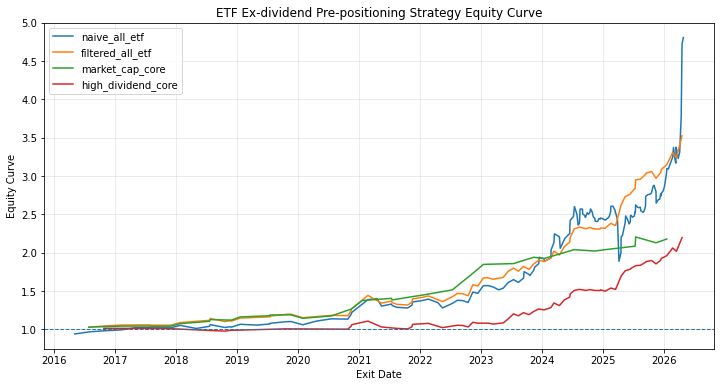

In [35]:
plt.figure(figsize=(12, 6))

for strategy_name, basket in strategy_basket_tables.items():
    if basket.empty:
        continue

    x = pd.to_datetime(basket["exit_date"]).to_numpy()
    y = basket["equity_curve"].to_numpy()

    plt.plot(
        x,
        y,
        label=strategy_name,
    )

plt.axhline(1, linestyle="--", linewidth=1)
plt.title("ETF Ex-dividend Pre-positioning Strategy Equity Curve")
plt.xlabel("Exit Date")
plt.ylabel("Equity Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 12. Drawdowns

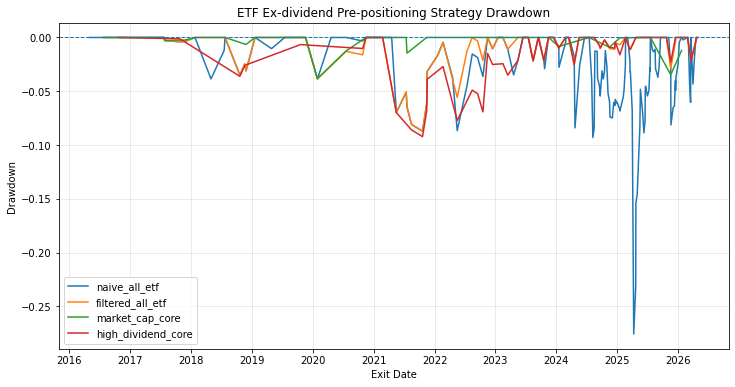

In [36]:
plt.figure(figsize=(12, 6))

for strategy_name, basket in strategy_basket_tables.items():
    if basket.empty:
        continue

    x = pd.to_datetime(basket["exit_date"]).to_numpy()
    y = basket["drawdown"].to_numpy()

    plt.plot(
        x,
        y,
        label=strategy_name,
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("ETF Ex-dividend Pre-positioning Strategy Drawdown")
plt.xlabel("Exit Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 13. Export strategy outputs

In [37]:
strategy_trade_summary.to_csv(
    OUTPUT_DIR / "strategy_trade_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

strategy_basket_summary.to_csv(
    OUTPUT_DIR / "strategy_basket_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

for strategy_name, trades in strategy_trade_tables.items():
    trades.to_csv(
        OUTPUT_DIR / f"{strategy_name}_trades.csv",
        index=False,
        encoding="utf-8-sig",
    )

for strategy_name, basket in strategy_basket_tables.items():
    basket.to_csv(
        OUTPUT_DIR / f"{strategy_name}_basket_returns.csv",
        index=False,
        encoding="utf-8-sig",
    )

for strategy_name, summary in strategy_by_symbol.items():
    summary.to_csv(
        OUTPUT_DIR / f"{strategy_name}_by_symbol.csv",
        index=False,
        encoding="utf-8-sig",
    )

for strategy_name, summary in strategy_by_year.items():
    summary.to_csv(
        OUTPUT_DIR / f"{strategy_name}_by_year.csv",
        index=False,
        encoding="utf-8-sig",
    )

print("Saved strategy outputs to:", OUTPUT_DIR)


Saved strategy outputs to: C:\Users\USER\Desktop\ETF-alpha-lab\data\strategy


## 14. Interpretation checklist

跑完後先不要急著宣稱策略有效，請依序檢查：

### 1. Naive All ETF 是否本身就有效？
如果 Naive All ETF 表現也不錯，代表全 ETF 除息前效應可能有策略化價值。

### 2. Filtered All ETF 是否優於 Naive All ETF？
若 Filtered All ETF 的平均報酬、勝率、profit factor 更好，且 max drawdown 更低，代表篩選規則有價值。

### 3. Market Cap Core 是否最穩？
若 0050 + 006208 的資金曲線最乾淨，策略主軸可能應改成「市值型 ETF 除息前卡位策略」。

### 4. High Dividend Core 是否有輔助價值？
若高股息核心版有效，可以作為 satellite strategy。

### 5. 年度是否穩定？
如果報酬集中在少數年份，要小心過度依賴特定市場環境。

### 6. 分 ETF 是否過度集中？
如果只靠一檔 ETF 撐起來，要降低策略敘事強度。

---

## Next steps

Strategy v2 建議加入：

1. announcement-date 可交易性檢查  
   - 只有在 entry_date 前已知 ex_date 的事件才允許交易
2. 流動性 filter  
   - 例如過去 20 日平均成交金額門檻
3. 滑價假設  
   - 例如額外扣 5 bps 或依成交量估計
4. 每日 portfolio simulation  
   - 處理資金占用、重疊持倉、單檔權重上限
